In [17]:

import re
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, UTC
import matplotlib.pyplot as plt


In [18]:
#Open data with pandas dataframe
df = pd.read_csv("./dataset/amazon_prime_titles.csv")
df.describe()

,release_year
count,9668.000000
mean,2008.341849
std,18.922482
min,1920.000000
25%,2007.000000
50%,2016.000000
75%,2019.000000
max,2021.000000


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       9668 non-null   str  
 1   type          9668 non-null   str  
 2   title         9668 non-null   str  
 3   director      7585 non-null   str  
 4   cast          8435 non-null   str  
 5   country       672 non-null    str  
 6   date_added    155 non-null    str  
 7   release_year  9668 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9668 non-null   str  
 10  listed_in     9668 non-null   str  
 11  description   9668 non-null   str  
dtypes: int64(1), str(11)
memory usage: 906.5 KB


In [20]:
df.shape

(9668, 12)

In [21]:

df.isnull().sum()  

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [22]:
df

print("--- Initial Missing Values ---")
print(df.isnull().sum())
print("\n-------------------------------\n")

# fill missing values with appropriate values 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unrated')
# create temp column to extract duration number and season/unit
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract('([a-zA-Z]+)')
# fill the new columns with appropriate values that I just created
df['duration_minutes'] = np.where(df['type'] == 'Movie', df['duration_num'], np.nan)
df['duration_seasons'] = np.where(df['type'] == 'TV Show', df['duration_num'], np.nan)

df
# drop the temporary columns used for cleaning
df = df.drop(columns=['duration_num', 'duration_unit']) 
 
#combine the two dataframes into one and reset the index
movies_cleaned  = df[(df['type'] == 'Movie') & (df['duration_minutes'] >= 10)]
tv_shows_cleaned = df[(df['type'] == 'TV Show') & (df['duration_seasons'] >= 1)]
df = pd.concat([movies_cleaned, tv_shows_cleaned]).reset_index(drop=True)

# drop duplicates based on title, type, and release_year columns
df = df.drop_duplicates(subset=['title', 'type', 'release_year'], keep='first').reset_index(drop=True)

# remove any leading or trailing whitespace from the text columns 
text_cols = ['title', 'type', 'rating', 'listed_in']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
 
df_temp = df
print("Sample of cleaned text columns:")
df_temp

--- Initial Missing Values ---
show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

-------------------------------

Sample of cleaned text columns:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,Unrated,113 min,"Comedy, Drama",A small fishing village must procure a local d...,113.0,NaN
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,110.0,NaN
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,Unrated,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,74.0,NaN
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,Unrated,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",69.0,NaN
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,Unrated,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,45.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9587,s9652,TV Show,Glass Room,Unknown,"Elizaveta Maiskaya, Vsevolod Boldin, Alexander...",Unknown,NaN,2019,16+,1 Season,Drama,Geography teacher Elena lives with her husband...,NaN,1.0
9588,s9656,TV Show,DaFUNdamentals Series,Unknown,"Emile Crawford, Randall Crawford, Jon Ward",Unknown,NaN,2021,TV-Y,1 Season,"Animation, Kids","Learn ""daFundamentals"" through song and fun ch...",NaN,1.0
9589,s9662,TV Show,Terrahawks,Unknown,"DENISE BRYER, WINDSOR DAVIES, JEREMY HITCHEN, ...",Unknown,NaN,1983,ALL,3 Seasons,TV Shows,"This thrilling, action-packed series saw Gerry...",NaN,3.0
9590,s9665,TV Show,Planet Patrol,Unknown,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unknown,NaN,2018,13+,4 Seasons,TV Shows,"This is Earth, 2100AD - and these are the adve...",NaN,4.0


In [23]:
print("--- Final Missing Values ---")
print(df.isnull().sum())

--- Final Missing Values ---
show_id                0
type                   0
title                  0
director               0
cast                   0
country                0
date_added          9437
release_year           0
rating                 0
duration               0
listed_in              0
description            0
duration_minutes    1854
duration_seasons    7738
dtype: int64


In [24]:
df.to_csv("./dataset/amazon_prime_titles_cleaned.csv", index=False)
data_Cleaned = pd.read_csv("./dataset/amazon_prime_titles_cleaned.csv")

In [25]:
data_Cleaned

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,Unrated,113 min,"Comedy, Drama",A small fishing village must procure a local d...,113.0,NaN
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,110.0,NaN
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,Unrated,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,74.0,NaN
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,Unrated,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",69.0,NaN
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,Unrated,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,45.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9587,s9652,TV Show,Glass Room,Unknown,"Elizaveta Maiskaya, Vsevolod Boldin, Alexander...",Unknown,NaN,2019,16+,1 Season,Drama,Geography teacher Elena lives with her husband...,NaN,1.0
9588,s9656,TV Show,DaFUNdamentals Series,Unknown,"Emile Crawford, Randall Crawford, Jon Ward",Unknown,NaN,2021,TV-Y,1 Season,"Animation, Kids","Learn ""daFundamentals"" through song and fun ch...",NaN,1.0
9589,s9662,TV Show,Terrahawks,Unknown,"DENISE BRYER, WINDSOR DAVIES, JEREMY HITCHEN, ...",Unknown,NaN,1983,ALL,3 Seasons,TV Shows,"This thrilling, action-packed series saw Gerry...",NaN,3.0
9590,s9665,TV Show,Planet Patrol,Unknown,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unknown,NaN,2018,13+,4 Seasons,TV Shows,"This is Earth, 2100AD - and these are the adve...",NaN,4.0


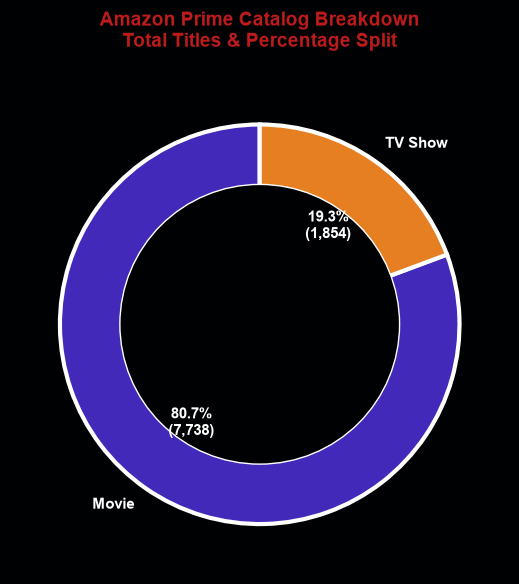

In [26]:
 
df = pd.read_csv("./dataset/amazon_prime_titles_cleaned.csv")
 
type_df = df['type'].value_counts().reset_index()
type_df.columns = ['content_type', 'total_count']
type_df.to_csv('./dataset/type_breakdown.csv', index=False)
type_df
type_df = pd.read_csv('./dataset/type_breakdown.csv')

#Visualize with pie chart
 
colors = ["#4329b9", '#e67e22']   

 
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:,})'   
    return my_autopct

 
plt.figure(figsize=(6, 6), facecolor="#000102")   

 
plt.pie(
    type_df['total_count'], 
    labels=type_df['content_type'], 
    autopct=make_autopct(type_df['total_count']),  
    startangle=90, 
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': 'white'},   
    wedgeprops={'edgecolor': 'white', 'linewidth': 3, 'antialiased': True}
)

 
centre_circle = plt.Circle((0,0), 0.70, fc="#000102")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

 
plt.title('Amazon Prime Catalog Breakdown\nTotal Titles & Percentage Split', fontsize=14, fontweight='bold', pad=20,color="#bd1b1b")
plt.tight_layout()

#save
plt.savefig('./dataset/type_breakdown.png', dpi=300)
plt.show()

In [27]:
type_df

,content_type,total_count
0,Movie,7738
1,TV Show,1854


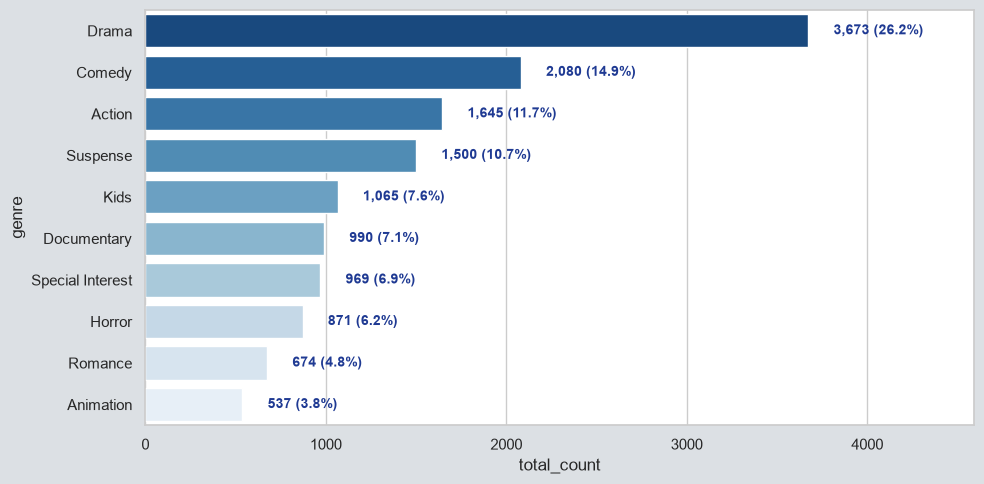

In [28]:
 
genres_exploded = df['listed_in'].str.split(', ').explode()
genre_df = genres_exploded.value_counts().reset_index().head(10)
genre_df.columns = ['genre', 'total_count']

genre_df.to_csv('./dataset/top_genres.csv', index=False)

#VISUALIZATION: Horizontal Bar Plot for Top 10 Genres
 
genre_df = pd.read_csv('./dataset/top_genres.csv')

 
plt.figure(figsize=(10, 5), facecolor="#DCE0E4")   
sns.set_theme(style="whitegrid")

 
ax = sns.barplot(
    x='total_count', 
    y='genre', 
    data=genre_df, 
    hue='genre',        
    palette='Blues_r',  
    legend=False
)

 
total_sum = genre_df['total_count'].sum()

 
for p in ax.patches:
    width = p.get_width() 
    if width > 0:
        percentage = (width / total_sum) * 100
        
        label = f'{int(width):,} ({percentage:.1f}%)' 
        
         
         
        ax.text(
            width + (total_sum * 0.01),       
            p.get_y() + p.get_height() / 2,   
            label,
            va='center', 
            ha='left', 
            fontsize=10, 
            fontweight='bold',
            color='#1F3A93'
        )
plt.xlim(0, genre_df['total_count'].max() * 1.25)
plt.tight_layout()

plt.savefig('./dataset/top_genres.png', dpi=300)
plt.show()

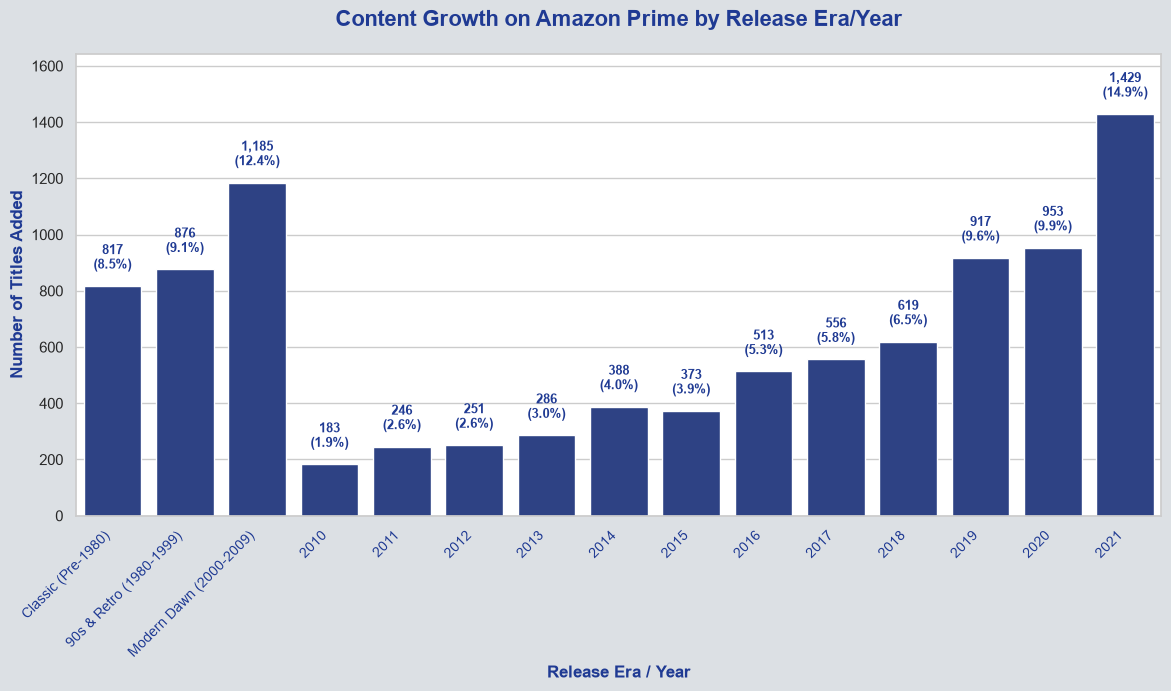

In [29]:
import os
 
#define a function to categorize the release year into eras
def get_era_every_year(year):
    if year < 1980:
        return 'Classic (Pre-1980)'
    elif year < 2000:
        return '90s & Retro (1980-1999)'
    elif year < 2010:
        return 'Modern Dawn (2000-2009)'
    else:
         
        return str(int(year))

 
df['time_period'] = df['release_year'].apply(get_era_every_year)

 
growth_df = df['time_period'].value_counts().reset_index()
growth_df.columns = ['time_period', 'titles_added']

 
def get_sort_key(period):
    if period == 'Classic (Pre-1980)':
        return 1920
    if period == '90s & Retro (1980-1999)':
        return 1980
    if period == 'Modern Dawn (2000-2009)':
        return 2000
    return int(period)   

 
growth_df['sort_key'] = growth_df['time_period'].apply(get_sort_key)
growth_df = growth_df.sort_values('sort_key').drop(columns=['sort_key']).reset_index(drop=True)

 
os.makedirs('./dataset', exist_ok=True)
growth_df.to_csv('./dataset/yearly_growth.csv', index=False)

growth_df


#VISUALIZE
 
growth_df = pd.read_csv('./dataset/yearly_growth.csv')

 
plt.figure(figsize=(14, 6), facecolor="#DCE0E4")
sns.set_theme(style="whitegrid")

 
total_titles = growth_df['titles_added'].sum()

 
 
ax = sns.barplot(
    x='time_period', 
    y='titles_added', 
    data=growth_df, 
    color='#1F3A93'
)

 
for p in ax.patches:
    height = p.get_height()
    if height > 0:   
        percentage = (height / total_titles) * 100
         
        label = f'{int(height):,}\n({percentage:.1f}%)'
        
         
         
        ax.text(
            p.get_x() + p.get_width() / 2,   
            height + (total_titles * 0.005),  
            label,
            va='bottom', 
            ha='center', 
            fontsize=9, 
            fontweight='bold',
            color='#1F3A93'
        )

 
plt.title('Content Growth on Amazon Prime by Release Era/Year', fontsize=16, fontweight='bold', pad=20, color="#1F3A93")
plt.xlabel('Release Era / Year', fontsize=12, fontweight='bold', color="#1F3A93")
plt.ylabel('Number of Titles Added', fontsize=12, fontweight='bold', color="#1F3A93")

 
plt.xticks(rotation=45, ha='right', fontsize=10, color="#1F3A93")

 
plt.ylim(0, growth_df['titles_added'].max() * 1.15)
#save
plt.savefig('./dataset/yearly_growth.png', dpi=300)
plt.show()

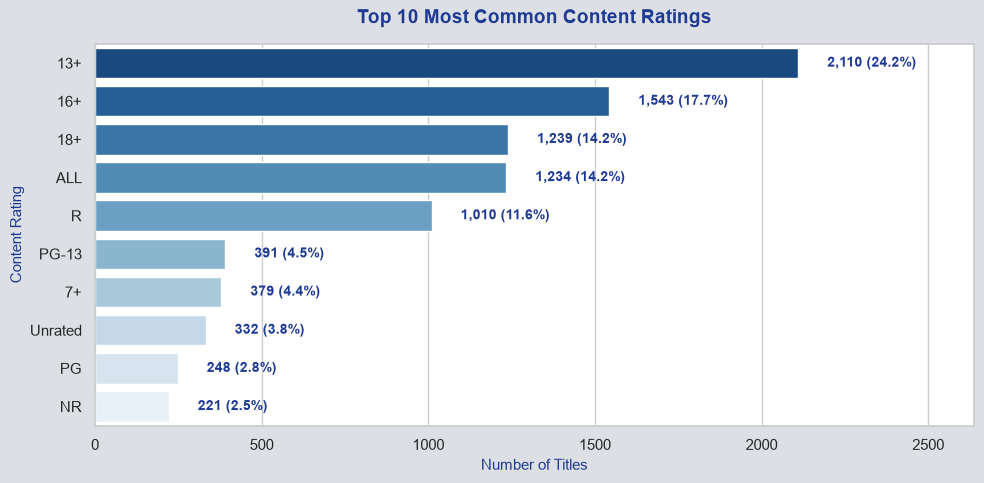

In [30]:
 
rating_df = df['rating'].value_counts().reset_index().head(10)
rating_df.columns = ['content_rating', 'total_count']

 
rating_df.to_csv('./dataset/rating_breakdown.csv', index=False)

 
rating_df

#VISUALIZATION: Horizontal Bar Plot for Top 10 Content Ratings

 
rating_df = pd.read_csv('./dataset/rating_breakdown.csv')

 
plt.figure(figsize=(10, 5), facecolor="#DCE0E4")   
sns.set_theme(style="whitegrid")

 
total_ratings = rating_df['total_count'].sum()

 
ax = sns.barplot(
    x='total_count', 
    y='content_rating', 
    data=rating_df, 
    hue='content_rating',   
    palette='Blues_r',       
    legend=False
)

 
for p in ax.patches:
    width = p.get_width()  
    if width > 0:
        percentage = (width / total_ratings) * 100
         
        label = f'{int(width):,} ({percentage:.1f}%)'
        
         
         
        ax.text(
            width + (total_ratings * 0.01),   
            p.get_y() + p.get_height() / 2,   
            label,
            va='center', 
            ha='left', 
            fontsize=10, 
            fontweight='bold',
            color='#1F3A93'
        )

 
plt.title('Top 10 Most Common Content Ratings', fontsize=14, fontweight='bold', pad=15, color="#1F3A93")
plt.xlabel('Number of Titles', fontsize=11, color="#1F3A93")
plt.ylabel('Content Rating', fontsize=11, color="#1F3A93")

 
plt.xlim(0, rating_df['total_count'].max() * 1.25)

 
plt.tight_layout()

#save
plt.savefig('./dataset/rating_breakdown.png', dpi=300)
plt.show()

10.0


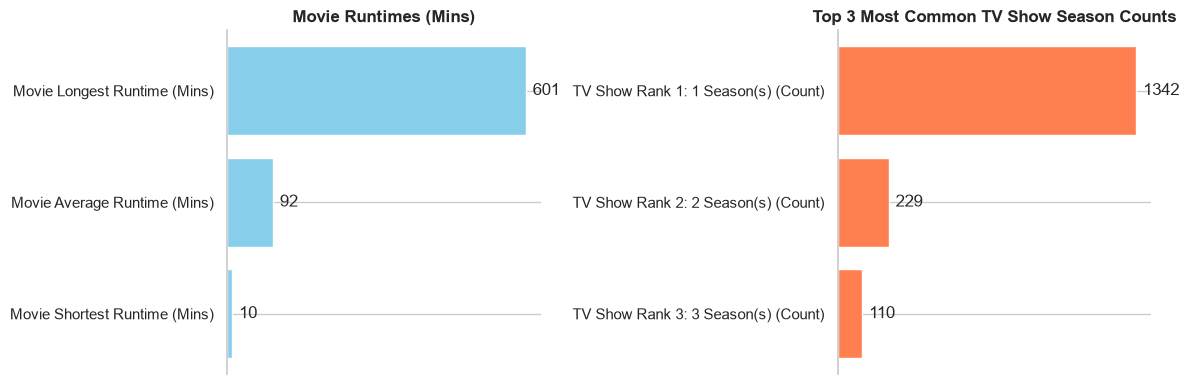

In [31]:
#Content DUration Metrics
 
movie_mask = df['type'] == 'Movie'
movie_avg = df.loc[movie_mask, 'duration_minutes'].mean()
movie_max = df.loc[movie_mask, 'duration_minutes'].max()
movie_min = df.loc[movie_mask, 'duration_minutes'].min()

print(movie_min)

 
tv_mask = df['type'] == 'TV Show'
 
top_tv_counts = df.loc[tv_mask, 'duration_seasons'].value_counts().head(3)

 
duration_data = {
    'metric_category': [
        'Movie Average Runtime (Mins)', 
        'Movie Longest Runtime (Mins)', 
        'Movie Shortest Runtime (Mins)'
    ],
    'metric_value': [
        round(movie_avg, 0),
        movie_max,
        movie_min
    ]
}

 
 
for rank, (season_num, show_count) in enumerate(top_tv_counts.items(), start=1):
    duration_data['metric_category'].append(f'TV Show Rank {rank}: {int(season_num)} Season(s) (Count)')
    duration_data['metric_value'].append(show_count)

 
duration_df = pd.DataFrame(duration_data)

 
duration_df.to_csv('./dataset/duration_metrics.csv', index=False)

 
duration_df


#VISUALIZE
import matplotlib.pyplot as plt

 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

 
categories = [('Movie', 'skyblue', 'Movie Runtimes (Mins)'), 
              ('TV Show', 'coral', 'Top 3 Most Common TV Show Season Counts')]  

for ax, (keyword, color, title) in zip(axes, categories):
     
     
    sub_df = duration_df[duration_df['metric_category'].str.contains(keyword)].sort_values('metric_value')
    
     
     
    bars = ax.barh(sub_df['metric_category'], sub_df['metric_value'], color=color)
    
     
     
    ax.bar_label(bars, padding=5, fmt='%g')
    
     
     
    ax.set_title(title, fontweight='bold')
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.set_xticks([])  

plt.tight_layout()
plt.savefig('./dataset/duration_metrics_minimal.png', dpi=300)
plt.show()

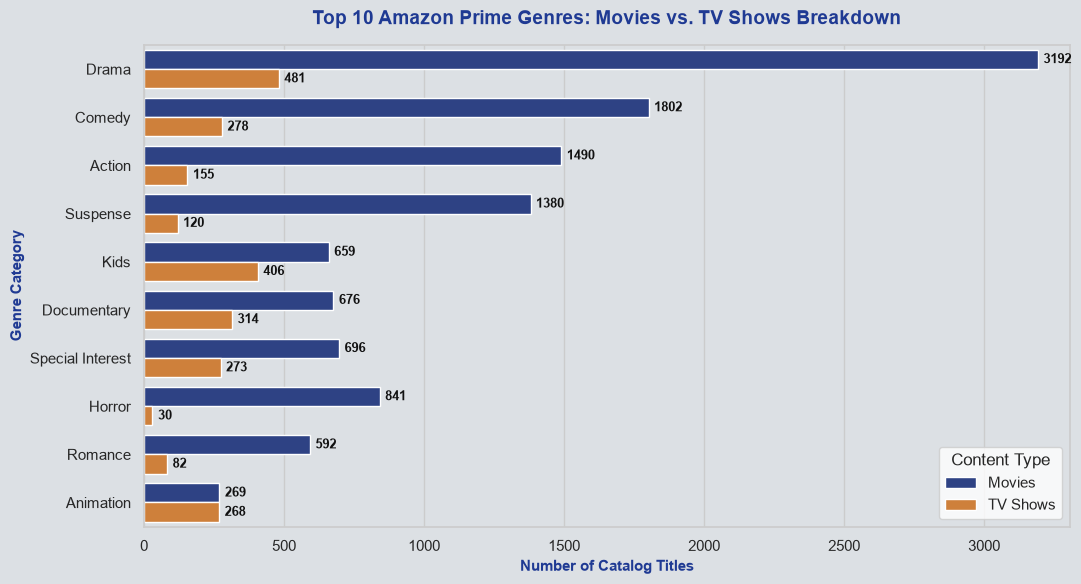

In [32]:
 
 
genre_type_exploded = df[['type', 'listed_in']].copy()
genre_type_exploded['listed_in'] = genre_type_exploded['listed_in'].str.split(', ')
 
genre_type_exploded = genre_type_exploded.explode('listed_in')
 

 
genre_type_exploded = genre_type_exploded.reset_index(drop=True)

 
genre_matrix = pd.crosstab(genre_type_exploded['listed_in'], genre_type_exploded['type']).reset_index()
 
genre_matrix.columns = ['genre', 'movie_count', 'tv_show_count']
 

 
genre_matrix['total_count'] = genre_matrix['movie_count'] + genre_matrix['tv_show_count']
genre_matrix = genre_matrix.sort_values(by='total_count', ascending=False).head(15).reset_index(drop=True).head(10)

 
genre_matrix.to_csv('./dataset/genre_type_matrix.csv', index=False)

 
genre_matrix

#Visualization: Grouped Bar Plot for Top 10 Genres Split by Movies vs TV Shows

 
genre_matrix = pd.read_csv('./dataset/genre_type_matrix.csv')

 
 
melted_genres = pd.melt(
    genre_matrix, 
    id_vars=['genre'], 
    value_vars=['movie_count', 'tv_show_count'],
    var_name='content_type', 
    value_name='count',
    ignore_index=False
)

 
melted_genres['content_type'] = melted_genres['content_type'].replace({
    'movie_count': 'Movies', 
    'tv_show_count': 'TV Shows'
})

 
plt.figure(figsize=(11, 6), facecolor="#DCE0E4")
sns.set_theme(style="whitegrid")

 
ax = sns.barplot(
    x='count', 
    y='genre', 
    hue='content_type', 
    data=melted_genres, 
    palette=['#1F3A93', '#e67e22']  
)

 
ax.set_facecolor('#DCE0E4')

 
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, fontweight='bold', padding=4, color='#111111')

 
plt.title('Top 10 Amazon Prime Genres: Movies vs. TV Shows Breakdown', fontsize=14, fontweight='bold', pad=15, color="#1F3A93")
plt.xlabel('Number of Catalog Titles', fontsize=11, fontweight='bold', color="#1F3A93")
plt.ylabel('Genre Category', fontsize=11, fontweight='bold', color="#1F3A93")

 
plt.legend(title='Content Type', loc='lower right', frameon=True)

 
plt.xlim(0, genre_matrix['total_count'].max() * 0.9)

plt.tight_layout()

#save
plt.savefig('./dataset/genre_type_breakdown.png', dpi=300)
plt.show()